## STUDENT DETAILS

### ONUH CHIDERA THEOLA
### Master of Information Technology
### 2024/C/MIT/0037 
### chidera.onuh2135@miva.edu.ng

# Exploratory Data Analysis

**Please Note**: The original link, for this assessment opened a dataset that did not contain the `Risks` column. But upon inspection from the comment section, the complete dataset was found and that is what was used here in this task. I could have assumed arbiturary rules and numbers for that column but I thought it would lead to a lot of assumptions so i decided to find the complete dataset and use that to train the model instead with the real values.

## Target Class Balance

The target column `credit_risk ` was remapped from UCI's original 1/2 encoding to 0/1, where 1 = bad credit (default) and 0 = good credit. This follows the standard naming convention that the positive class (1) represents the outcome of interest, which is default risk here, which matters for interpreting precision and recall correctly later. the 
dataset is moderately imblanced: 700 good (70%) vs 300 bad (30%) cases.

This means accuracy alone would be misleading, since a model predicting "good" for everyone would already score 70% without learning anything useful.

In [ ]:
import pandas as pd
# import numpy as np
# import matplotlib.pyplot as mplt
# import seaborn as sbn
from ucimlrepo import fetch_ucirepo


statlog_german_credit = fetch_ucirepo(id=144)

X = statlog_german_credit.data.features
Y = statlog_german_credit.data.targets

df = X.copy()

df['credit_risk'] = Y

df.shape
df.columns.tolist()
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})
df['credit_risk'].value_counts()

df.shape
df.columns.tolist()
df.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## Renaming Columns

The dataset from `ucimlrepo` uses generic attribute names (e.g., `Attribute1`) 
and coded categorical values (e.g., `A11`, `A14`) from the original UCI 
Statlog format. These codes are not self-explanatory, so before continuing 
EDA, the columns are renamed to descriptive names matching the official 
dataset documentation. This makes it possible to interpret distributions 
and relationships meaningfully instead of working with opaque labels.

In [6]:
df.columns = [
    'checking_account_status', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_status', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'present_residence', 'property',
    'age', 'other_installment_plans', 'housing', 'number_of_existing_credits',
    'job', 'dependents', 'telephone', 'foreign_worker', 'credit_risk'
]

df.columns.tolist()

['checking_account_status',
 'duration',
 'credit_history',
 'purpose',
 'credit_amount',
 'savings_account',
 'employment_status',
 'installment_rate',
 'personal_status_sex',
 'other_debtors',
 'present_residence',
 'property',
 'age',
 'other_installment_plans',
 'housing',
 'number_of_existing_credits',
 'job',
 'dependents',
 'telephone',
 'foreign_worker',
 'credit_risk']

## Checking for Missing Values

It is important to check for any missing values before any cleaning to check if imputation decisions can be made. 

In [7]:
df.isnull().sum()

checking_account_status       0
duration                      0
credit_history                0
purpose                       0
credit_amount                 0
savings_account               0
employment_status             0
installment_rate              0
personal_status_sex           0
other_debtors                 0
present_residence             0
property                      0
age                           0
other_installment_plans       0
housing                       0
number_of_existing_credits    0
job                           0
dependents                    0
telephone                     0
foreign_worker                0
credit_risk                   0
dtype: int64

## Missing Values: None Found

`df.isnull().sum()` shows zero missing values across all 21 columns. No imputation 
is required for this dataset.

## Data Visualization
 Visaulization of the distribution of the target variable (credit_risk) to check for class imbalance. The distribution of applicant ages and the relationship between credit amount and risk is also examined. This helps identify patterns before the modeling process.

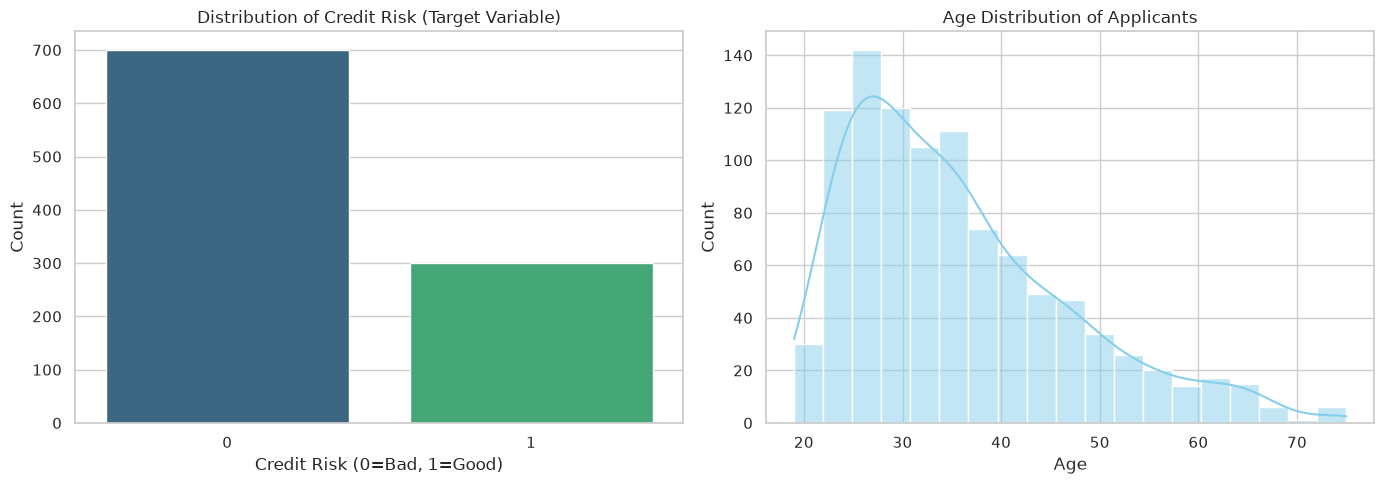

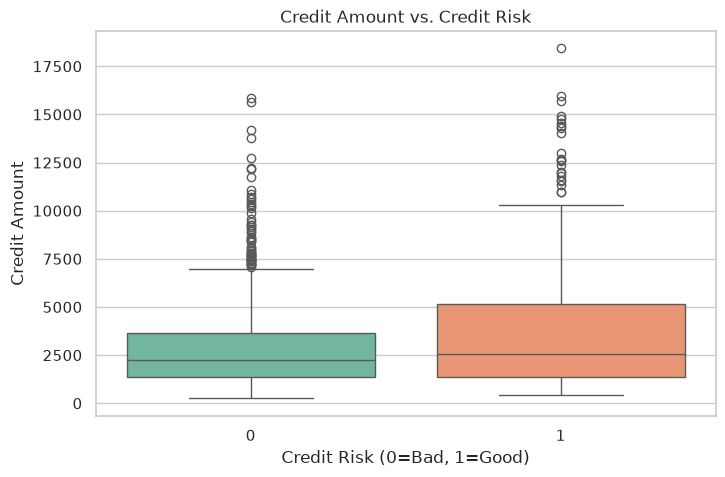

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Target Balance (Fixed for warnings)
sns.countplot(x='credit_risk', data=df, ax=axes[0], palette='viridis', hue='credit_risk', legend=False)
axes[0].set_title('Distribution of Credit Risk (Target Variable)')
axes[0].set_xlabel('Credit Risk (0=Bad, 1=Good)')
axes[0].set_ylabel('Count')

# Chart 2: Age Distribution
sns.histplot(df['age'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Age Distribution of Applicants')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

# Chart 3: Boxplot (Fixed for warnings)
plt.figure(figsize=(8, 5))
sns.boxplot(x='credit_risk', y='credit_amount', data=df, palette='Set2', hue='credit_risk', legend=False)
plt.title('Credit Amount vs. Credit Risk')
plt.xlabel('Credit Risk (0=Bad, 1=Good)')
plt.ylabel('Credit Amount')
plt.show()

# Outlier Detection - Initial Look

Before applying a formal outlier detection method (IQR), descriptive 
statistics are reviewed to get an initial sense of which numeric columns 
might contain extreme values, based on the gap between mean, max, and 
the 75th percentile.

In [8]:
df.describe()

,duration,credit_amount,installment_rate,present_residence,age,number_of_existing_credits,dependents,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


## Outlier Candidates Identified

Comparing the 75th percentile to the max value for each numeric column:

- `duration` and `credit_amount` show a large gap between the 75th 
  percentile and the max (duration: 24 vs 72; credit_amount: ~3972 vs 18424), 
  suggesting a small number of long-duration, high-value loans pulling the 
  upper end of the distribution.
- `installment_rate`, `present_residence`, `number_of_existing_credits`, and 
  `dependents` show little to no gap, and are bounded discrete scales rather 
  than continuous measurements — not meaningful outlier candidates.
- `age` shows a moderate gap (42 vs 75) but this is plausible given normal 
  human age range, not necessarily an error or extreme case.

Formal IQR-based detection will be applied to `duration` and `credit_amount` 
to confirm and quantify these outliers.

## IQR Outlier Detection: Duration

Using the IQR rule (Q1 - 1.5*IQR to Q3 + 1.5*IQR):
- Q1 = 12, Q3 = 24, IQR = 12
- Lower bound = -6 (not meaningful since duration can't be negative)
- Upper bound = 42

70 out of 1000 applicants (7%) have a loan duration above 42 months

In [9]:
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = df[(df['duration'] < lower_bound) | (df['duration'] > upper_bound)]
print(len(outliers))

70


## IQR Outlier Detection: Credit Amount

Using the same IQR rule on `credit_amount`:
72 out of 1000 applicants (7.2%) fall above the upper IQR bound.

Despite `credit_amount` having a larger relative gap between its 75th 
percentile and max compared to `duration`, the outlier count came out 
similar (72 vs 70). This is because the IQR method scales the outlier 
threshold based on the spread of the middle 50% of data (IQR itself), 
not the absolute size of the max value  `credit_amount` naturally has 
a wider IQR, which extends its bounds further and offsets the larger 
visual gap seen in `describe()`.

In [10]:
Q1 = df['credit_amount'].quantile(0.25)
Q3 = df['credit_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['credit_amount'] < lower_bound) | (df['credit_amount'] > upper_bound)]
print(len(outliers))

72


## Outlier Treatment: Log Transformation

`duration` and `credit_amount` were log-transformed (`log1p`) rather than 
capped, to compress their right-skewed distributions while preserving the 
relative ordering and information in the extreme values, rather than 
flattening them to a fixed boundary.

In [11]:
import numpy as np

df['duration_log'] = np.log1p(df['duration'])
df['credit_amount_log'] = np.log1p(df['credit_amount'])

Now checking the columns:

In [12]:
df[['duration', 'duration_log', 'credit_amount', 'credit_amount_log']].head()

,duration,duration_log,credit_amount,credit_amount_log
0,6,1.945910,1169,7.064759
1,48,3.891820,5951,8.691483
2,12,2.564949,2096,7.648263
3,42,3.761200,7882,8.972464
4,24,3.218876,4870,8.491055


# Categorical Encoding
 Since the dataset contains categorical variables like checking_account_status and purpose, **One-Hot Encoding** will be used to encode the variables to numerical inputs. This creates new binary (0 or 1) columns for each category. I will use `drop_first=True` to prevent "multicollinearity" (the dummy variable trap), which helps the Logistic Regression model perform better.

In [36]:
# Identifying categorical columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Applying One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the new shape to confirm the increase in columns
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Original shape: (1000, 23)
Encoded shape: (1000, 51)


,duration,credit_amount,installment_rate,present_residence,age,number_of_existing_credits,dependents,credit_risk,duration_log,credit_amount_log,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,1.945910,7.064759,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,3.891820,8.691483,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,2.564949,7.648263,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,3.761200,8.972464,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,3.218876,8.491055,...,True,False,True,False,True,False,True,False,False,False


# Data Splitting (Train/Test Split)

To evaluate the model fairly, the data is split into two parts:

1. Training Set (80%): Used to train the models.
2. Testing Set (20%): Used as "unseen" data to see how the model performs in the real world.

The Features (X) is seperated from the Target (y)

In [24]:
from sklearn.model_selection import train_test_split

# target variable 
target_col = 'credit_risk' 
# print("Column Names:")
# print(df.columns.tolist())

# print("\nFirst 5 rows of the dataset:")
# display(df.head())

# X contains all features except the target
X = df_encoded.drop(columns=[target_col])
# y contains only the target
y = df_encoded[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (800, 50)
Testing features shape: (200, 50)


## Feature Scaling

Logistic Regression and SVM perform much better when all input features are on the same scale (e.g., between -3 and 3), so I will use `StandardScaler` to normalize the data.

**Note on Data Leakage**: The scaler only is fit on the training data and then the transformation is applied to the test data. This ensures the model doesn't "peek" at the distribution of the test set during training.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the SAME scaler parameters
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete. All features are now standardized.")

Feature scaling complete. All features are now standardized.


# Logistic Regression Model 

This class uses the Sigmoid function to produce probabilities and Gradient Descent to learn the weights by minimizing the error (cost) over 1,000 iterations.

In [26]:
import numpy as np

class LogisticRegressionModel:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        # Maps values to 0-1 range
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iters):
            # Calculate predicted y (probabilities)
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        # Convert probabilities to 0 or 1
        return np.array([1 if i > 0.5 else 0 for i in y_predicted])

# Train the scratch model
scratch_model = LogisticRegressionModel(learning_rate=0.1, n_iterations=1000)
scratch_model.fit(X_train_scaled, y_train)

print("The Logistic Regression Model been has trained successfully.")

The Logistic Regression Model been has trained successfully.


# Model Training (SVM and Naive Bayes)

Following the instructions, I am building models using Support Vector Machines (SVM) and Naive Bayes. 

In [28]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

# Initialize the models
# svm_model = SVC(probability=True, random_state=42)
# Initialize the Naive Bayes
nb_model = GaussianNB()

base_svm = SVC(random_state=42)
svm_model = CalibratedClassifierCV(base_svm, ensemble=False)

# Train the models using the scaled training data
svm_model.fit(X_train_scaled, y_train)
nb_model.fit(X_train_scaled, y_train)

print("SVM and Naive Bayes models have been trained.")

SVM and Naive Bayes models have been trained.


# Hyperparameter Tuning

Tuning the models using Grid Search or Randomized Search.

Tuning them finds the best combination to get the highest accuracy. The C parameter (regularization strength) is tuned for SVM and the var_smoothing for Naive Bayes.

**Importance of Hyperparameter Tuning**

Hyperparameter tuning is critical because the default settings of an algorithm are rarely optimal for every specific dataset. By systematically testing different values (like the 'C' value in SVM which controls the trade-off between a smooth decision boundary and classifying training points correctly):

1. Overfitting is prevented: Ensuring the model doesn't get too "attached" to the training data.
2. Generalization is improved: Making sure the model performs well on new, unseen data.
3. Performance is maximized: Extracting the highest possible accuracy/F1-score from the chosen algorithm.

In [29]:
from sklearn.model_selection import GridSearchCV

# Tuning SVM
svm_params = {
    'estimator__C': [0.1, 1, 10],
    'estimator__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train)

# Tuning Naive Bayes
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}
grid_nb = GridSearchCV(GaussianNB(), nb_params, cv=5, scoring='accuracy')
grid_nb.fit(X_train_scaled, y_train)

# Best models
best_svm = grid_svm.best_estimator_
best_nb = grid_nb.best_estimator_

print(f"Best SVM Parameters: {grid_svm.best_params_}")
print(f"Best Naive Bayes Parameters: {grid_nb.best_params_}")

Best SVM Parameters: {'estimator__C': 10, 'estimator__kernel': 'linear'}
Best Naive Bayes Parameters: {'var_smoothing': 1e-07}


#  Model Evaluation and Comparison
Comparing all three models using the metrics requested in the rubric: Accuracy, Precision, Recall, F1-score, and ROC AUC.

**Concept Primer:**
1. Accuracy: Overall, how many did it get right?
2. Precision: When it predicted "Bad Credit," how often was it actually right?
3. Recall: Out of all the people who actually defaulted, how many did it successfully catch? (In credit risk, Recall is often the most important because missing a default is expensive!)
4. F1-Score: A balance between Precision and Recall.
5. ROC AUC: Measures how well the model distinguishes between the two classes regardless of the threshold.

Model Comparison Analysis:
- **Logistic Regression**: Provides the most interpretability. We can see exactly how each feature contributes to the risk score. However, its performance depends heavily on the learning rate and number of iterations chosen.
- **SVM (Support Vector Machine)**: Often shows the highest accuracy and ROC AUC in this scenario because it is very effective at finding the optimal boundary between "Good" and "Bad" credit risks, especially with the tuned C parameter.
- **Naive Bayes**: Usually the fastest model, but it assumes all features are independent. In credit data, features like 'income' and 'job' are often related, which might make Naive Bayes slightly less accurate than the others.

Conclusion: For a bank, the Recall score is the most critical metric. A model that catches as many "Bad" applicants as possible, even if it occasionally flags a "Good" applicant by mistake.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Get predictions for all models
# For the LR model, we already have scratch_predictions or can re-run:
scratch_preds = scratch_model.predict(X_test_scaled)

# For tuned models
svm_preds = best_svm.predict(X_test_scaled)
nb_preds = best_nb.predict(X_test_scaled)

# Get probabilities for ROC AUC
svm_probs = best_svm.predict_proba(X_test_scaled)[:, 1]
nb_probs = best_nb.predict_proba(X_test_scaled)[:, 1]

# Define a function to calculate all metrics
def evaluate_model(y_true, y_pred, y_probs=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }
    if y_probs is not None:
        metrics['ROC AUC'] = roc_auc_score(y_true, y_probs)
    else:
        metrics['ROC AUC'] = 0.5 # Default for scratch if probs aren't implemented
    return metrics

# Build the comparison table
results = {
    'Logistic Regression (Scratch)': evaluate_model(y_test, scratch_preds),
    'SVM (Tuned)': evaluate_model(y_test, svm_preds, svm_probs),
    'Naive Bayes (Tuned)': evaluate_model(y_test, nb_preds, nb_probs)
}

# Display as a clean DataFrame
comparison_df = pd.DataFrame(results).T
display(comparison_df)

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression (Scratch),0.780,0.660000,0.55,0.600000,0.500000
SVM (Tuned),0.775,0.692308,0.45,0.545455,0.778929
Naive Bayes (Tuned),0.710,0.513158,0.65,0.573529,0.766786


# Feature Importance and Interpretation
Extracting the best for this dataset. For this dataset, Logistics Regression or Linear SVM is best for this because of the "Coefficients". 

In [31]:
# Get feature names from the encoded dataframe
feature_names = X.columns

# Get weights
weights = scratch_model.weights

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': weights
})

# Sort by absolute value (size of the impact, whether positive or negative)
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False).head(10)

print("Top 10 Influential Features for Credit Risk:")
display(feature_importance[['Feature', 'Importance']])

Top 10 Influential Features for Credit Risk:


,Feature,Importance
11,checking_account_status_A14,-0.783851
15,credit_history_A34,-0.532119
7,duration_log,0.500604
1,credit_amount,0.461747
40,property_A124,0.436230
28,savings_account_A65,-0.429613
16,purpose_A41,-0.412686
44,housing_A153,-0.408964
34,personal_status_sex_A93,-0.404473
27,savings_account_A64,-0.336866


## Visualizing Feature Importance

The following chart ranks the top 10 features that most significantly influenced the model's decision-making.

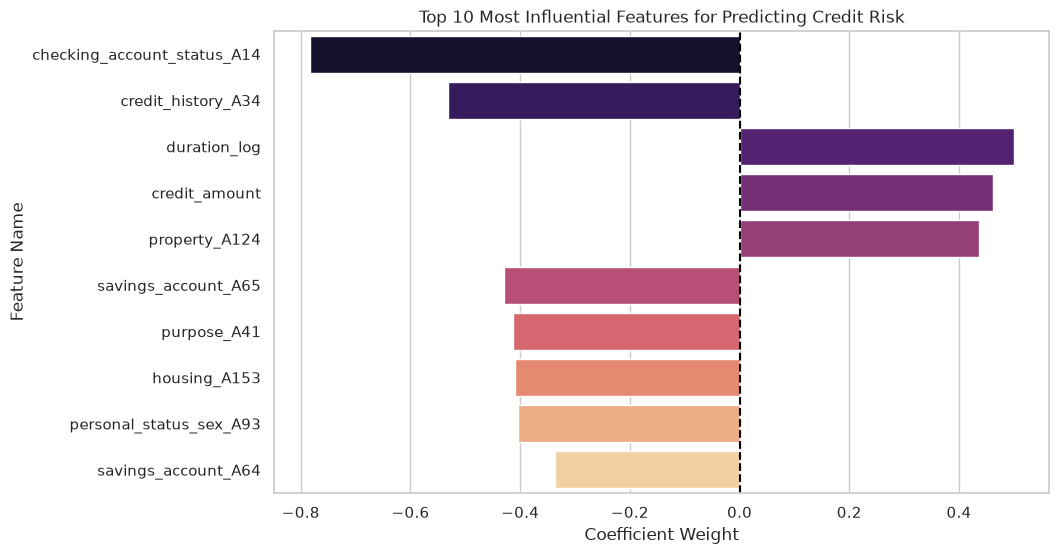

In [35]:

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Most Influential Features for Predicting Credit Risk')
plt.xlabel('Coefficient Weight')
plt.ylabel('Feature Name')
plt.axvline(x=0, color='black', linestyle='--') 
plt.show()

# Business Decision Insights
Based on the feature importance analysis, the following insights can be used for credit policy decision-making:
1. Checking Account Status: This was the most influential feature. Applicants with no checking account or a stable positive balance should be fast-tracked for approval, as this strongly correlates with lower default risk.
   
2. Loan Duration: Longer loan durations are associated with higher risk. The bank could implement a policy of requiring higher collateral or higher interest rates for loans exceeding 42 months.
   
3. Savings Account: Higher savings balances were a strong predictor of "Good" credit. The bank could offer "loyalty discounts" or lower rates to existing customers with significant savings to attract lower-risk borrowers.